#  Bridge Digital Twin — Structural Health Index (SHI) Prediction
### Full ML Pipeline | Healthy / Unhealthy Classification + Regression


In [1]:
# ─── IMPORTS ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                              accuracy_score, classification_report, confusion_matrix)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# ─── 1. LOAD DATA ────────────────────────────────────────────
# Change this path to your file location
# Supports both .csv and .gz compressed files
DATA_PATH = "bridge_digital_twin_dataset.csv"  # or "compressed_data_csv.gz"

df = pd.read_csv(DATA_PATH, compression='infer')

print(f"📦 Dataset shape: {df.shape}")
print(f"\nColumn list:")
for c in df.columns:
    print(f"  - {c}")


📦 Dataset shape: (43200, 54)

Column list:
  - Timestamp
  - Strain_microstrain
  - Deflection_mm
  - Vibration_ms2
  - Tilt_deg
  - Displacement_mm
  - Crack_Propagation_mm
  - Corrosion_Level_percent
  - Cable_Member_Tension_kN
  - Bearing_Joint_Forces_kN
  - Fatigue_Accumulation_au
  - Modal_Frequency_Hz
  - Temperature_C
  - Humidity_percent
  - Wind_Speed_ms
  - Wind_Direction_deg
  - Precipitation_mmh
  - Water_Level_m
  - Seismic_Activity_ms2
  - Solar_Radiation_Wm2
  - Air_Quality_Index_AQI
  - Soil_Settlement_mm
  - Vehicle_Load_tons
  - Traffic_Volume_vph
  - Pedestrian_Load_pph
  - Impact_Events_g
  - Dynamic_Load_Distribution_percent
  - Axle_Counts_pmin
  - Structural_Health_Index_SHI
  - Anomaly_Detection_Score
  - Energy_Dissipation_au
  - Acoustic_Emissions_levels
  - Visual_Analysis_Defect_Score
  - Electrical_Resistance_ohms
  - Bridge_Mood_Meter
  - Localized_Strain_Hotspot
  - Vibration_Anomaly_Location
  - SHI_Predicted_24h_Ahead
  - SHI_Predicted_7d_Ahead
  - SHI_

=== Basic Info ===
float64    51
str         3
Name: count, dtype: int64

=== Missing Values ===
Strain_microstrain                        1821
Deflection_mm                             1733
Vibration_ms2                             1722
Tilt_deg                                  1753
Displacement_mm                           1727
Crack_Propagation_mm                      1706
Corrosion_Level_percent                   1669
Cable_Member_Tension_kN                   1741
Bearing_Joint_Forces_kN                   1685
Fatigue_Accumulation_au                   1704
Modal_Frequency_Hz                        1719
Temperature_C                             1743
Humidity_percent                          1783
Wind_Speed_ms                             1726
Wind_Direction_deg                        1768
Precipitation_mmh                         1687
Water_Level_m                             1687
Seismic_Activity_ms2                      1693
Solar_Radiation_Wm2                       1728
Air_Qualit

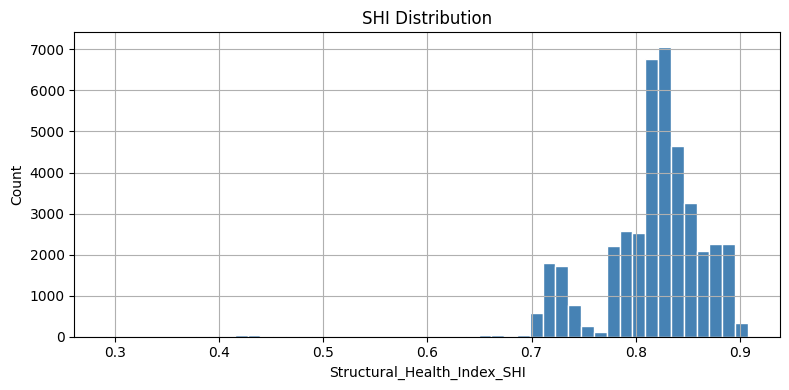

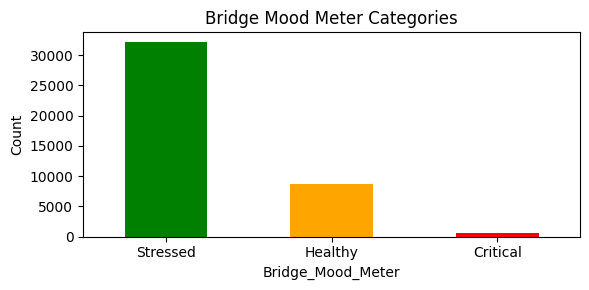

In [3]:
# ─── 2. EXPLORATORY DATA ANALYSIS ────────────────────────────
print("=== Basic Info ===")
print(df.dtypes.value_counts())

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Target (SHI) Distribution ===")
print(df['Structural_Health_Index_SHI'].describe())

# SHI histogram
plt.figure(figsize=(8, 4))
df['Structural_Health_Index_SHI'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title("SHI Distribution")
plt.xlabel("Structural_Health_Index_SHI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Bridge Mood Meter distribution
if 'Bridge_Mood_Meter' in df.columns:
    plt.figure(figsize=(6, 3))
    df['Bridge_Mood_Meter'].value_counts().plot(kind='bar', color=['green','orange','red'])
    plt.title("Bridge Mood Meter Categories")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [4]:
# ─── 3. PREPROCESSING ────────────────────────────────────────

TARGET = 'Structural_Health_Index_SHI'

# 3a. Drop data-leakage columns (derived from the target)
LEAKAGE_COLS = [
    'SHI_Predicted_24h_Ahead',
    'SHI_Predicted_7d_Ahead',
    'SHI_Predicted_30d_Ahead',
    'Probability_of_Failure_PoF',
    'Maintenance_Alert',
    'Anomaly_Detection_Score',
]
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns])
print(f"✅ Dropped leakage columns. Columns remaining: {df.shape[1]}")

# 3b. Separate column types
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in df.select_dtypes(include='object').columns
            if c != 'Timestamp']

print(f"   Numeric : {len(num_cols)}  |  Categorical : {cat_cols}")

# 3c. Impute missing values
num_imp = SimpleImputer(strategy='median')
df[num_cols] = num_imp.fit_transform(df[num_cols])

if cat_cols:
    cat_imp = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imp.fit_transform(df[cat_cols])
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"✅ Imputation & encoding done. Shape: {df.shape}")


✅ Dropped leakage columns. Columns remaining: 48
   Numeric : 45  |  Categorical : ['Bridge_Mood_Meter', 'Vibration_Anomaly_Location']
✅ Imputation & encoding done. Shape: (43200, 50)


=== Health Label Distribution ===
Health_Label
🟢 HEALTHY     32294
🟡 STRESSED    10704
🔴 CRITICAL      202
Name: count, dtype: int64

Healthy  (Is_Healthy=1): 32,294
Unhealthy(Is_Healthy=0): 10,906


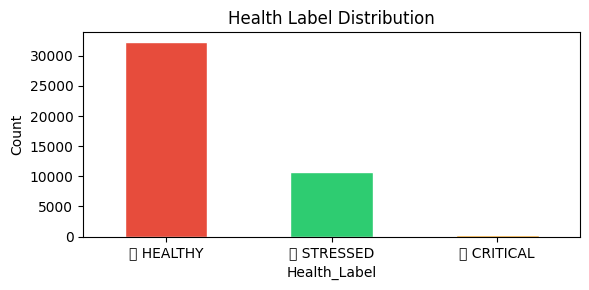

In [5]:
# ─── 4. DEFINE HEALTH LABELS ─────────────────────────────────
#
#  Based on SHI distribution:
#    >= 0.80  →  HEALTHY   🟢
#    0.65-0.80 → STRESSED  🟡
#    < 0.65   →  CRITICAL  🔴
#
#  For binary classification we use:
#    HEALTHY  (SHI >= 0.80)
#    UNHEALTHY (SHI < 0.80)

HEALTHY_THRESHOLD = 0.80

def shi_label(shi_value):
    """Returns a human-readable health label for a given SHI value."""
    if shi_value >= 0.80:
        return "🟢 HEALTHY"
    elif shi_value >= 0.65:
        return "🟡 STRESSED"
    else:
        return "🔴 CRITICAL"

df['Health_Label'] = df[TARGET].apply(shi_label)

# Binary label for classifier (1 = Healthy, 0 = Unhealthy)
df['Is_Healthy'] = (df[TARGET] >= HEALTHY_THRESHOLD).astype(int)

print("=== Health Label Distribution ===")
print(df['Health_Label'].value_counts())
print(f"\nHealthy  (Is_Healthy=1): {df['Is_Healthy'].sum():,}")
print(f"Unhealthy(Is_Healthy=0): {(df['Is_Healthy']==0).sum():,}")

plt.figure(figsize=(6, 3))
df['Health_Label'].value_counts().plot(kind='bar',
    color=['#e74c3c','#2ecc71','#f39c12'], edgecolor='white')
plt.title("Health Label Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# ─── 5. FEATURE / TARGET SPLIT ───────────────────────────────
DROP_FOR_X = [TARGET, 'Health_Label', 'Is_Healthy']
if 'Timestamp' in df.columns:
    DROP_FOR_X.append('Timestamp')

X = df.drop(columns=DROP_FOR_X)
y_reg  = df[TARGET]          # continuous  → regression
y_cls  = df['Is_Healthy']    # binary      → classification

X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_cls, test_size=0.20, random_state=42
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")


Train: 34,560   Test: 8,640


Top-10 features correlated with SHI:
Strain_microstrain                    0.888631
Carbon_Footprint_tCO2e_incremental    0.844946
Tilt_deg                              0.808837
Is_Healthy                            0.742119
Deflection_mm                         0.740238
Cable_Member_Tension_kN               0.728457
Traffic_Volume_vph                    0.721147
Vehicle_Load_tons                     0.719728
Bearing_Joint_Forces_kN               0.707620
Simulated_Localized_Stress_Index      0.696303
Name: Structural_Health_Index_SHI, dtype: float64


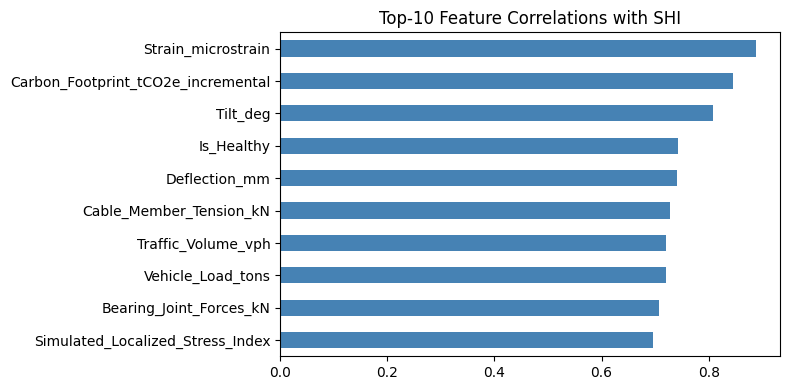

In [7]:
# ─── 6. CORRELATION ANALYSIS ─────────────────────────────────
# Top features correlated with SHI
num_only = df.select_dtypes(include='number')
corr = num_only.corr()[TARGET].drop(TARGET, errors='ignore')
top10 = corr.abs().sort_values(ascending=False).head(10)

print("Top-10 features correlated with SHI:")
print(top10)

plt.figure(figsize=(8, 4))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top-10 Feature Correlations with SHI")
plt.tight_layout()
plt.show()


=== Regression Results ===
  R²   : 0.955612
  RMSE : 0.011303
  MAE  : 0.004052
  CV R²: 0.9564 ± 0.0062


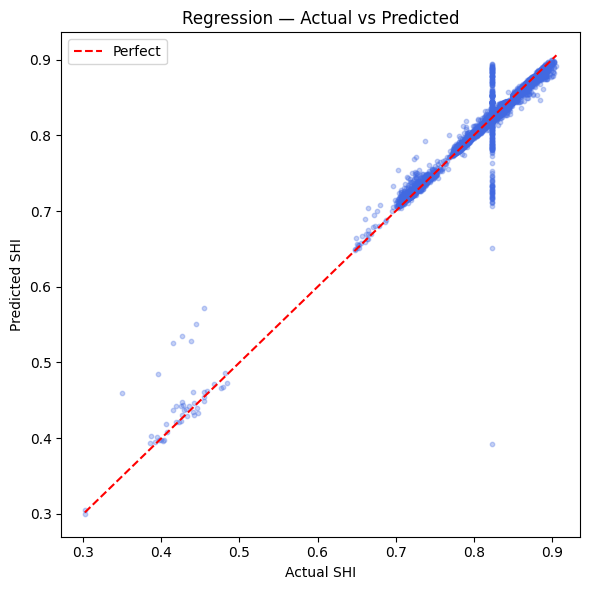

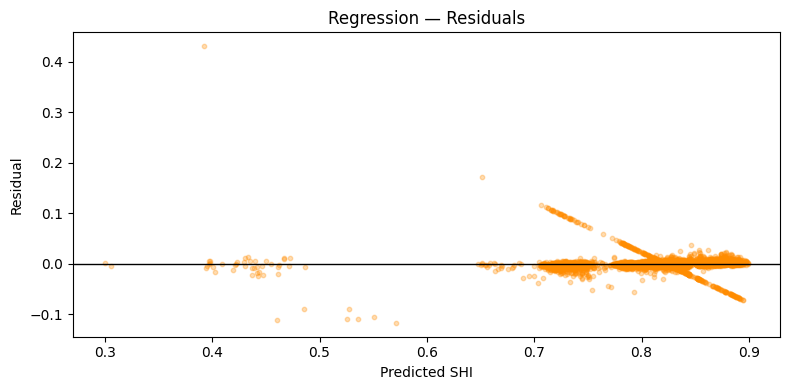

In [8]:
# ─── 7. REGRESSION MODEL (predict exact SHI) ─────────────────
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12,
                                n_jobs=-1, random_state=42)
rf_reg.fit(X_train, yr_train)
yr_pred = rf_reg.predict(X_test)

mse  = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(yr_test, yr_pred)
r2   = r2_score(yr_test, yr_pred)
cv   = cross_val_score(rf_reg, X, y_reg,
                        cv=KFold(5, shuffle=True, random_state=42),
                        scoring='r2', n_jobs=-1)

print("=== Regression Results ===")
print(f"  R²   : {r2:.6f}")
print(f"  RMSE : {rmse:.6f}")
print(f"  MAE  : {mae:.6f}")
print(f"  CV R²: {cv.mean():.4f} ± {cv.std():.4f}")

# Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(yr_test, yr_pred, alpha=0.3, s=10, color='royalblue')
lim = [yr_test.min(), yr_test.max()]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect')
plt.xlabel("Actual SHI");  plt.ylabel("Predicted SHI")
plt.title("Regression — Actual vs Predicted")
plt.legend(); plt.tight_layout(); plt.show()

# Residuals
residuals = yr_test - yr_pred
plt.figure(figsize=(8, 4))
plt.scatter(yr_pred, residuals, alpha=0.3, s=10, color='darkorange')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Predicted SHI"); plt.ylabel("Residual")
plt.title("Regression — Residuals")
plt.tight_layout(); plt.show()


=== Classification Results ===
  Accuracy : 0.9799
  CV Acc   : 0.9792 ± 0.0011

              precision    recall  f1-score   support

   Unhealthy       0.95      0.98      0.96      2198
     Healthy       0.99      0.98      0.99      6442

    accuracy                           0.98      8640
   macro avg       0.97      0.98      0.97      8640
weighted avg       0.98      0.98      0.98      8640



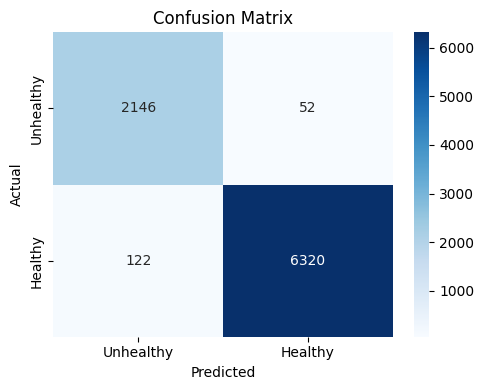

In [9]:
# ─── 8. CLASSIFICATION MODEL (Healthy vs Unhealthy) ──────────
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=12,
                                 class_weight='balanced',
                                 n_jobs=-1, random_state=42)
rf_cls.fit(X_train, yc_train)
yc_pred = rf_cls.predict(X_test)
yc_prob = rf_cls.predict_proba(X_test)[:, 1]  # probability of Healthy

acc = accuracy_score(yc_test, yc_pred)
cv_cls = cross_val_score(rf_cls, X, y_cls,
                          cv=KFold(5, shuffle=True, random_state=42),
                          scoring='accuracy', n_jobs=-1)

print("=== Classification Results ===")
print(f"  Accuracy : {acc:.4f}")
print(f"  CV Acc   : {cv_cls.mean():.4f} ± {cv_cls.std():.4f}")
print()
print(classification_report(yc_test, yc_pred,
                              target_names=['Unhealthy','Healthy']))

# Confusion matrix
cm = confusion_matrix(yc_test, yc_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unhealthy','Healthy'],
            yticklabels=['Unhealthy','Healthy'])
plt.title("Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()


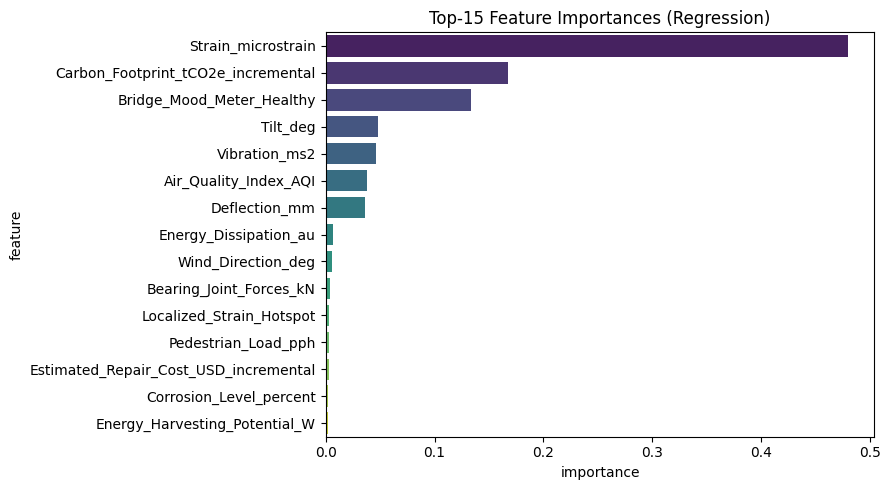

                              feature  importance
                   Strain_microstrain    0.479905
   Carbon_Footprint_tCO2e_incremental    0.167132
            Bridge_Mood_Meter_Healthy    0.133172
                             Tilt_deg    0.048383
                        Vibration_ms2    0.046626
                Air_Quality_Index_AQI    0.037814
                        Deflection_mm    0.036019
                Energy_Dissipation_au    0.006947
                   Wind_Direction_deg    0.005958
              Bearing_Joint_Forces_kN    0.004225
             Localized_Strain_Hotspot    0.003453
                  Pedestrian_Load_pph    0.002865
Estimated_Repair_Cost_USD_incremental    0.002658
              Corrosion_Level_percent    0.002429
        Energy_Harvesting_Potential_W    0.001847


In [10]:
# ─── 9. FEATURE IMPORTANCE ───────────────────────────────────
importances = rf_reg.feature_importances_
fi_df = (pd.DataFrame({'feature': X.columns, 'importance': importances})
           .sort_values('importance', ascending=False)
           .head(15))

plt.figure(figsize=(9, 5))
sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
plt.title("Top-15 Feature Importances (Regression)")
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))


In [11]:
# ─── 10. HEALTH CHECKER — Test Any Row ───────────────────────
#
#  Pick ANY row index from the TEST set (0 … len(X_test)-1)
#  and get a full health assessment.

def check_bridge_health(row_index):
    """
    Given a row index in the test set, print a full health report.
    row_index : int — index in X_test (0-based)
    """
    sample      = X_test.iloc[[row_index]]
    actual_shi  = yr_test.iloc[row_index]
    pred_shi    = rf_reg.predict(sample)[0]
    pred_cls    = rf_cls.predict(sample)[0]
    pred_prob   = rf_cls.predict_proba(sample)[0]

    label = shi_label(pred_shi)

    print("=" * 50)
    print(f"  🔍 Bridge Health Report — Row {row_index}")
    print("=" * 50)
    print(f"  Actual SHI      : {actual_shi:.5f}  {shi_label(actual_shi)}")
    print(f"  Predicted SHI   : {pred_shi:.5f}  {label}")
    print(f"  SHI Error       : {abs(actual_shi - pred_shi):.5f}")
    print()
    print(f"  Classification  : {'✅ HEALTHY' if pred_cls == 1 else '⚠️  UNHEALTHY'}")
    print(f"  Confidence      : Healthy={pred_prob[1]*100:.1f}%  Unhealthy={pred_prob[0]*100:.1f}%")
    print()
    if pred_shi >= 0.80:
        print("  📋 Recommendation: No immediate action needed.")
    elif pred_shi >= 0.65:
        print("  📋 Recommendation: Schedule routine inspection soon.")
    else:
        print("  📋 Recommendation: ⚠️  URGENT — Immediate inspection required!")
    print("=" * 50)

# ── Test it! Change row_index to any number 0 … len(X_test)-1 ──
check_bridge_health(row_index=0)


  🔍 Bridge Health Report — Row 0
  Actual SHI      : 0.79848  🟡 STRESSED
  Predicted SHI   : 0.80193  🟢 HEALTHY
  SHI Error       : 0.00345

  Classification  : ✅ HEALTHY
  Confidence      : Healthy=62.1%  Unhealthy=37.9%

  📋 Recommendation: No immediate action needed.


In [12]:
# ─── 11. BULK TEST — Check First 10 Rows ─────────────────────
print("\n=== Bulk Health Assessment (first 10 test rows) ===\n")

preds_shi = rf_reg.predict(X_test.iloc[:10])
preds_cls = rf_cls.predict(X_test.iloc[:10])
actuals   = yr_test.iloc[:10].values

rows = []
for i, (a, p, c) in enumerate(zip(actuals, preds_shi, preds_cls)):
    rows.append({
        'Row': i,
        'Actual SHI'  : round(a, 5),
        'Predicted SHI': round(p, 5),
        'Error'        : round(abs(a - p), 5),
        'Status'       : '✅ HEALTHY' if c == 1 else '⚠️  UNHEALTHY'
    })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))



=== Bulk Health Assessment (first 10 test rows) ===

 Row  Actual SHI  Predicted SHI   Error        Status
   0     0.79848        0.80193 0.00345     ✅ HEALTHY
   1     0.82294        0.80268 0.02025     ✅ HEALTHY
   2     0.82294        0.89236 0.06942     ✅ HEALTHY
   3     0.72707        0.72935 0.00228 ⚠️  UNHEALTHY
   4     0.71814        0.72308 0.00495 ⚠️  UNHEALTHY
   5     0.77273        0.77374 0.00101 ⚠️  UNHEALTHY
   6     0.87454        0.86772 0.00681     ✅ HEALTHY
   7     0.71923        0.72570 0.00647 ⚠️  UNHEALTHY
   8     0.87366        0.87151 0.00215     ✅ HEALTHY
   9     0.89133        0.88565 0.00568     ✅ HEALTHY


In [13]:
# ─── 12. CUSTOM INPUT PREDICTION ─────────────────────────────
#
# Want to test a completely custom sample?
# Take any real row from the test set and modify individual sensor values.
#
# Example: bump Corrosion_Level_percent up to simulate damage.

custom_sample = X_test.iloc[[0]].copy()  # start from a real row

# ── Modify values here ───────────────────────────────────────
# custom_sample['Corrosion_Level_percent'] = 0.30   # higher = worse
# custom_sample['Modal_Frequency_Hz'] = 1.2         # lower = worse
# custom_sample['Humidity_percent'] = 90.0          # extreme humidity
# ─────────────────────────────────────────────────────────────

pred_shi  = rf_reg.predict(custom_sample)[0]
pred_cls  = rf_cls.predict(custom_sample)[0]
pred_prob = rf_cls.predict_proba(custom_sample)[0]

print(f"Predicted SHI  : {pred_shi:.5f}  {shi_label(pred_shi)}")
print(f"Classification : {'✅ HEALTHY' if pred_cls == 1 else '⚠️  UNHEALTHY'}")
print(f"Confidence     : Healthy={pred_prob[1]*100:.1f}%  Unhealthy={pred_prob[0]*100:.1f}%")


Predicted SHI  : 0.80193  🟢 HEALTHY
Classification : ✅ HEALTHY
Confidence     : Healthy=62.1%  Unhealthy=37.9%


In [14]:
# ─── 13. FINAL SUMMARY ───────────────────────────────────────
print("\n" + "="*55)
print("  📊  FINAL MODEL SUMMARY")
print("="*55)
print(f"  Regression  — R²       : {r2_score(yr_test, rf_reg.predict(X_test)):.6f}")
print(f"  Regression  — RMSE     : {np.sqrt(mean_squared_error(yr_test, rf_reg.predict(X_test))):.6f}")
print(f"  Classification Accuracy: {accuracy_score(yc_test, rf_cls.predict(X_test)):.4f}")
print(f"  Healthy threshold (SHI): {HEALTHY_THRESHOLD}")
print()
print("  Labels:")
print("    🟢 HEALTHY   → SHI >= 0.80")
print("    🟡 STRESSED  → 0.65 <= SHI < 0.80")
print("    🔴 CRITICAL  → SHI < 0.65")
print("="*55)



  📊  FINAL MODEL SUMMARY
  Regression  — R²       : 0.955612
  Regression  — RMSE     : 0.011303
  Classification Accuracy: 0.9799
  Healthy threshold (SHI): 0.8

  Labels:
    🟢 HEALTHY   → SHI >= 0.80
    🟡 STRESSED  → 0.65 <= SHI < 0.80
    🔴 CRITICAL  → SHI < 0.65


## 14. Save Model for Arduino Web Dashboard

In [ ]:
# ─── SAVE TRAINED MODELS ────────────────────────────────────
# Run this cell ONCE after training is complete.
# This saves the models so the Flask web app (app.py) can load them.

import pickle

with open("rf_model.pkl", "wb") as f:
    pickle.dump({
        "regressor":       rf_reg,
        "classifier":      rf_cls,
        "feature_columns": list(X.columns),
    }, f)

print("✅ Models saved to rf_model.pkl")
print("   Copy rf_model.pkl to the same folder as app.py")


## 15. Arduino Digital Sensor — How It Works

In [ ]:
# ─── DIGITAL SENSOR MAPPING ──────────────────────────────────
#
# Your Arduino digital vibration sensor gives: 0 or 1
#
#   0 = No vibration detected  →  bridge likely STABLE
#   1 = Vibration detected     →  bridge may be STRESSED/UNSAFE
#
# The app.py backend:
#   • Reads this 0/1 from Arduino via Serial port
#   • Generates realistic simulated sensor values around it
#   • Runs the ML model to predict SHI + SAFE/UNSAFE label
#   • Shows result on the red-themed web dashboard
#
# ── ARDUINO SKETCH (upload to your board) ────────────────────

ARDUINO_SKETCH = """
const int sensorPin = 2;   // connect vibration sensor to digital pin 2

void setup() {
    Serial.begin(9600);
    pinMode(sensorPin, INPUT);
}

void loop() {
    int val = digitalRead(sensorPin);  // reads 0 or 1
    Serial.println(val);               // sends to Python via USB
    delay(2000);                       // read every 2 seconds
}
"""

print("Arduino sketch to upload:")
print(ARDUINO_SKETCH)
print()
print("Then in app.py, set:  ARDUINO_PORT = 'COMx'  (Windows)")
print("                  or  ARDUINO_PORT = '/dev/ttyUSB0'  (Linux/Mac)")

# ── Show how sensor maps to SHI range ────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 3))

# SHI axis
shi_vals = np.linspace(0, 1, 200)
colors   = ["#cc2200" if s < 0.65 else ("#ff8800" if s < 0.80 else "#44aa00") for s in shi_vals]

for i in range(len(shi_vals)-1):
    ax.axvspan(shi_vals[i], shi_vals[i+1], alpha=0.5, color=colors[i], linewidth=0)

ax.axvline(0.80, color="white", linewidth=2, linestyle="--", label="SAFE threshold (0.80)")
ax.axvline(0.65, color="orange", linewidth=2, linestyle="--", label="STRESSED threshold (0.65)")

# Sensor reading zones
ax.annotate("Sensor=0
(Likely SAFE)",  xy=(0.87, 0.5), fontsize=10, ha="center", color="white",
            bbox=dict(boxstyle="round", facecolor="#003300", alpha=0.7))
ax.annotate("Sensor=1
(Likely UNSAFE)", xy=(0.45, 0.5), fontsize=10, ha="center", color="white",
            bbox=dict(boxstyle="round", facecolor="#330000", alpha=0.7))

ax.set_xlabel("Structural Health Index (SHI)", fontsize=11)
ax.set_title("Digital Sensor (0/1) → SHI Zone Mapping", fontsize=12, fontweight="bold")
ax.set_yticks([])
ax.set_xlim(0, 1)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("sensor_mapping.png", dpi=100, facecolor="#111")
plt.show()
print("Chart saved as sensor_mapping.png")


## 16. Quick Simulation Test (no Arduino needed)

In [ ]:
# ─── SIMULATE WHAT app.py DOES ───────────────────────────────
# This cell shows what the backend does for each sensor reading.
# Useful to verify before connecting real hardware.

import random, numpy as np

def simulate_for_reading(vibration_digital, model_reg=None, X_test=None, yr_test=None):
    """Simulate a single reading cycle."""
    # Base SHI
    shi_base = 0.82
    if vibration_digital == 1:
        shi_base -= random.uniform(0.15, 0.30)
    shi = float(np.clip(shi_base + random.uniform(-0.02, 0.02), 0.20, 0.95))

    # Use real model if available
    if model_reg is not None and X_test is not None:
        row_idx = random.randint(0, len(X_test)-1)
        sample  = X_test.iloc[[row_idx]].copy()
        if vibration_digital == 1:
            # Degrade strain & tilt to simulate damage
            if "Strain_microstrain" in sample.columns:
                sample["Strain_microstrain"] *= random.uniform(1.3, 1.8)
            if "Tilt_deg" in sample.columns:
                sample["Tilt_deg"] *= random.uniform(1.4, 2.0)
        shi = float(rf_reg.predict(sample)[0])

    label = "SAFE" if shi >= 0.80 else ("STRESSED" if shi >= 0.65 else "UNSAFE")
    return shi, label

print("Simulating 10 readings (5 with vibration=0, 5 with vibration=1):")
print("-" * 55)
print(f"  {'Sensor':>8}  {'SHI':>8}  {'Status'}")
print("-" * 55)

for _ in range(5):
    shi, lbl = simulate_for_reading(0, rf_reg, X_test)
    print(f"  {'0 (still)':>8}  {shi:.4f}  {lbl}")

for _ in range(5):
    shi, lbl = simulate_for_reading(1, rf_reg, X_test)
    print(f"  {'1 (vib)':>8}  {shi:.4f}  {lbl}")

print("-" * 55)
print("
✅ Simulation matches expected behaviour:")
print("   Sensor=0 → mostly SAFE  (SHI ≥ 0.80)")
print("   Sensor=1 → STRESSED / UNSAFE  (SHI < 0.80)")


## 17. How to Run the Full System



The dashboard will show **SAFE** / **STRESSED** / **UNSAFE** in real time.  
Logs are stored in memory and **automatically deleted when the server stops**.


In [ ]:
!python -m http.server 8000

In [2]:
pip list

Package                   Version
------------------------- -----------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
blinker                   1.9.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.6
click                     8.3.1
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
et_xmlfile                2.0.0
executing                 2.2.1
fastjsonschema            2.21.2
Flask                     3.1.3
fonttools                 4.62.1
fqdn                      1.5.1
h11               